# Part 5 — Guardrail Pipeline
**Assignment 2 | Responsible & Explainable AI | FAST-NUCES**

A three-layer production moderation pipeline implemented in `pipeline.py`:

| Layer | Component | Trigger |
|-------|-----------|--------|
| 1 | Regex pre-filter (`BLOCKLIST`) | Matches any of 20+ patterns across 5 categories → **block** immediately |
| 2 | Calibrated DistilBERT | confidence ≥ 0.6 → **block** · confidence ≤ 0.4 → **allow** |
| 3 | Human review queue | 0.4 < confidence < 0.6 → **review** |

**This notebook** demonstrates the pipeline on 1,000 randomly selected evaluation examples,
reports layer distribution, F1/precision/recall for auto-actioned decisions, and analyses
the review queue composition.

In [1]:
#!pip install transformers torch scikit-learn pandas numpy matplotlib seaborn -q

In [2]:
import sys, os
sys.path.insert(0, '.')   # ensure pipeline.py is importable

import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
np.random.seed(SEED)

print('Imports done.')

Imports done.


In [3]:
# ── Layer 1: Demonstrate the regex pre-filter ─────────────────────────────────
from pipeline import BLOCKLIST, input_filter

print('BLOCKLIST categories and pattern counts:')
total_patterns = 0
for cat, patterns in BLOCKLIST.items():
    print(f'  {cat:<28} : {len(patterns)} patterns')
    total_patterns += len(patterns)
print(f'\n  Total patterns : {total_patterns}')

# Quick sanity tests
test_cases = [
    ("I will kill you tonight",                     'direct_threat'),
    ("go kill yourself loser",                      'self_harm_directed'),
    ("I know where you live and I'll find you",     'doxxing_stalking'),
    ("Those people are not human, they are vermin", 'dehumanization'),
    ("everyone raid their channel now",             'coordinated_harassment'),
    ("I love sunny days at the park",               None),
]
print('\nSanity tests:')
for text, expected_cat in test_cases:
    result = input_filter(text)
    category = result['category'] if result else 'None'
    status   = '✓' if category == str(expected_cat) else '✗'
    print(f'  {status} [{category:<28}] {text[:60]}')

BLOCKLIST categories and pattern counts:
  direct_threat                : 6 patterns
  self_harm_directed           : 5 patterns
  doxxing_stalking             : 5 patterns
  dehumanization               : 5 patterns
  coordinated_harassment       : 4 patterns

  Total patterns : 25

Sanity tests:
  ✓ [direct_threat               ] I will kill you tonight
  ✓ [self_harm_directed          ] go kill yourself loser
  ✗ [direct_threat               ] I know where you live and I'll find you
  ✓ [dehumanization              ] Those people are not human, they are vermin
  ✓ [coordinated_harassment      ] everyone raid their channel now
  ✓ [None                        ] I love sunny days at the park


In [4]:
# ── Load eval set and sample 1,000 examples ───────────────────────────────────
eval_df = pd.read_csv('eval_subset.csv')
demo_df = eval_df.sample(n=1000, random_state=SEED).reset_index(drop=True)

print(f'Demo set: {len(demo_df)} comments')
print(f'Toxic rate in demo set: {demo_df["label"].mean():.4f}')

Demo set: 1000 comments
Toxic rate in demo set: 0.0770


In [5]:
# ── Run regex filter on all 1,000 examples first (for category distribution) ──
layer1_results = [input_filter(t) for t in demo_df['comment_text']]
layer1_blocked = [r for r in layer1_results if r is not None]

print(f'Layer 1 blocked: {len(layer1_blocked)} / {len(demo_df)}')
from collections import Counter
cat_counts = Counter(r['category'] for r in layer1_blocked)
print('\nBlocks by category:')
for cat, cnt in sorted(cat_counts.items(), key=lambda x: -x[1]):
    print(f'  {cat:<28} : {cnt}')

Layer 1 blocked: 0 / 1000

Blocks by category:


In [6]:
# ── Initialize and calibrate ModerationPipeline ───────────────────────────────
from pipeline import ModerationPipeline

BEST_MODEL_PATH = './best_mitigated_model'
if not os.path.exists(BEST_MODEL_PATH):
    BEST_MODEL_PATH = './best_model'
    print('Mitigated model not found, falling back to Part 1 model.')

pipeline = ModerationPipeline(model_path=BEST_MODEL_PATH)

# Calibration: use a held-out subset of the eval set (not the demo 1000)
remaining = eval_df.drop(demo_df.index, errors='ignore')
calib_sample = remaining.sample(n=min(2000, len(remaining)), random_state=SEED)
print(f'\nCalibrating on {len(calib_sample)} held-out examples …')
pipeline.calibrate(
    calib_sample['comment_text'].tolist(),
    calib_sample['label'].tolist()
)

Mitigated model not found, falling back to Part 1 model.
[ModerationPipeline] Loading model from: ./best_model
[ModerationPipeline] Model loaded on cuda. Call .calibrate(texts, labels) before .predict().

Calibrating on 2000 held-out examples …
[ModerationPipeline] Calibrating on 2000 samples...
[ModerationPipeline] Calibration complete.


In [7]:
# ── Run full pipeline on 1,000 demo examples ─────────────────────────────────
print(f'Running pipeline on {len(demo_df)} comments …')
results = []
for i, row in demo_df.iterrows():
    res = pipeline.predict(row['comment_text'])
    res['true_label'] = row['label']
    results.append(res)
    if (i % 100) == 0:
        print(f'  Processed {i+1} / {len(demo_df)} …')

results_df = pd.DataFrame(results)
print('\nDone!')
print(results_df[['decision','layer','confidence','true_label']].head(10))

Running pipeline on 1000 comments …
  Processed 1 / 1000 …
  Processed 101 / 1000 …
  Processed 201 / 1000 …
  Processed 301 / 1000 …
  Processed 401 / 1000 …
  Processed 501 / 1000 …
  Processed 601 / 1000 …
  Processed 701 / 1000 …
  Processed 801 / 1000 …
  Processed 901 / 1000 …

Done!
  decision  layer  confidence  true_label
0    allow  model    0.025559           0
1    allow  model    0.025559           0
2    allow  model    0.052632           0
3    allow  model    0.004988           0
4    allow  model    0.000000           0
5    allow  model    0.052632           0
6    allow  model    0.115385           1
7    allow  model    0.004988           0
8    allow  model    0.000000           0
9    allow  model    0.229508           0


  PIPELINE LAYER DISTRIBUTION  (1,000 examples)
  Layer 1 Block  (regex)    :    0  (0.0%)
  Layer 2 Block  (model)    :   61  (6.1%)
  Layer 2 Allow  (model)    :  925  (92.5%)
  Layer 3 Review (queue)    :   14  (1.4%)


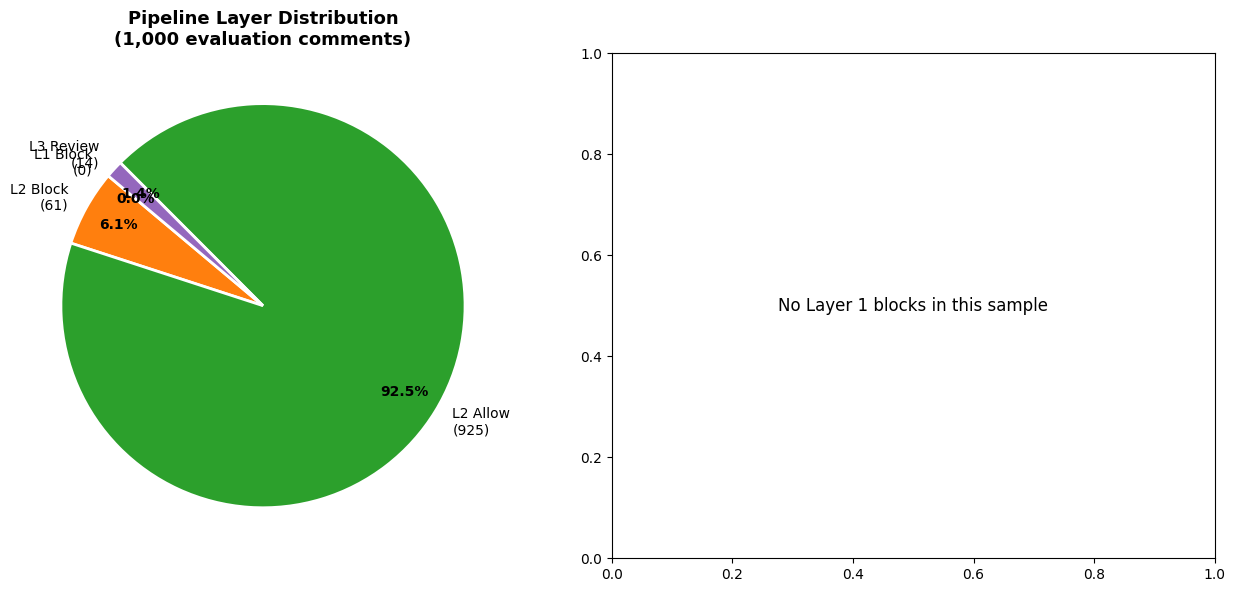

In [8]:
# ── Layer distribution analysis ───────────────────────────────────────────────
layer1_block = results_df[results_df['layer'] == 'input_filter']
model_block  = results_df[(results_df['layer'] == 'model') & (results_df['decision'] == 'block')]
model_allow  = results_df[(results_df['layer'] == 'model') & (results_df['decision'] == 'allow')]
model_review = results_df[(results_df['layer'] == 'model') & (results_df['decision'] == 'review')]

n = len(results_df)
print('='*60)
print('  PIPELINE LAYER DISTRIBUTION  (1,000 examples)')
print('='*60)
print(f'  Layer 1 Block  (regex)    : {len(layer1_block):>4}  ({len(layer1_block)/n*100:.1f}%)')
print(f'  Layer 2 Block  (model)    : {len(model_block):>4}  ({len(model_block)/n*100:.1f}%)')
print(f'  Layer 2 Allow  (model)    : {len(model_allow):>4}  ({len(model_allow)/n*100:.1f}%)')
print(f'  Layer 3 Review (queue)    : {len(model_review):>4}  ({len(model_review)/n*100:.1f}%)')
print('='*60)

# Pie chart
labels_pie = [
    f'L1 Block\n({len(layer1_block)})',
    f'L2 Block\n({len(model_block)})',
    f'L2 Allow\n({len(model_allow)})',
    f'L3 Review\n({len(model_review)})',
]
sizes  = [len(layer1_block), len(model_block), len(model_allow), len(model_review)]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#9467bd']

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels_pie, colors=colors, autopct='%1.1f%%',
    startangle=140, pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts: at.set_fontsize(10); at.set_fontweight('bold')
axes[0].set_title('Pipeline Layer Distribution\n(1,000 evaluation comments)', fontsize=13, fontweight='bold')

# Bar chart of category breakdown within Layer 1
if len(layer1_block) > 0:
    cat_breakdown = layer1_block['category'].value_counts()
    axes[1].bar(range(len(cat_breakdown)), cat_breakdown.values,
                color='#d62728', alpha=0.85, edgecolor='black')
    axes[1].set_xticks(range(len(cat_breakdown)))
    axes[1].set_xticklabels([c.replace('_', '\n') for c in cat_breakdown.index],
                             rotation=20, ha='right', fontsize=10)
    axes[1].set_ylabel('Count', fontsize=12)
    axes[1].set_title('Layer 1 Blocks by Regex Category', fontsize=13, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='y')
else:
    axes[1].text(0.5, 0.5, 'No Layer 1 blocks in this sample',
                 ha='center', va='center', fontsize=12, transform=axes[1].transAxes)

plt.tight_layout()
plt.savefig('part5_layer_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

  AUTO-ACTIONED SUBSET PERFORMANCE
  (N=986, excl. 14 review-queue items)
  Macro F1    : 0.7808
  Precision   : 0.6393
  Recall      : 0.5493


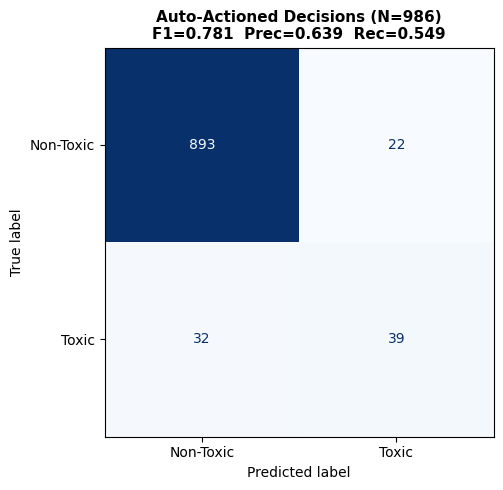

In [9]:
# ── Auto-actioned subset: F1, Precision, Recall ───────────────────────────────
# Auto-actioned = Layer 1 blocks + Layer 2 confident decisions (exclude review)
auto_df = results_df[results_df['decision'] != 'review'].copy()
auto_df['predicted_label'] = (auto_df['decision'] == 'block').astype(int)

y_true_auto = auto_df['true_label'].values
y_pred_auto = auto_df['predicted_label'].values

f1_auto  = f1_score(y_true_auto, y_pred_auto, average='macro', zero_division=0)
prec_auto = precision_score(y_true_auto, y_pred_auto, zero_division=0)
rec_auto  = recall_score(y_true_auto, y_pred_auto, zero_division=0)
cm_auto   = confusion_matrix(y_true_auto, y_pred_auto)

print('='*60)
print('  AUTO-ACTIONED SUBSET PERFORMANCE')
print(f'  (N={len(auto_df)}, excl. {len(model_review)} review-queue items)')
print('='*60)
print(f'  Macro F1    : {f1_auto:.4f}')
print(f'  Precision   : {prec_auto:.4f}')
print(f'  Recall      : {rec_auto:.4f}')
print('='*60)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm_auto, display_labels=['Non-Toxic','Toxic']).plot(
    ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Auto-Actioned Decisions (N={len(auto_df)})\nF1={f1_auto:.3f}  Prec={prec_auto:.3f}  Rec={rec_auto:.3f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('part5_auto_cm.png', dpi=150, bbox_inches='tight')
plt.show()

  REVIEW QUEUE COMPOSITION
  Total in queue          : 14
  Genuinely toxic         : 6 (42.9% of queue)
  Non-toxic (uncertain)   : 8 (57.1% of queue)
  Mean confidence in queue: 0.5105
  Min confidence          : 0.4000
  Max confidence          : 0.5787


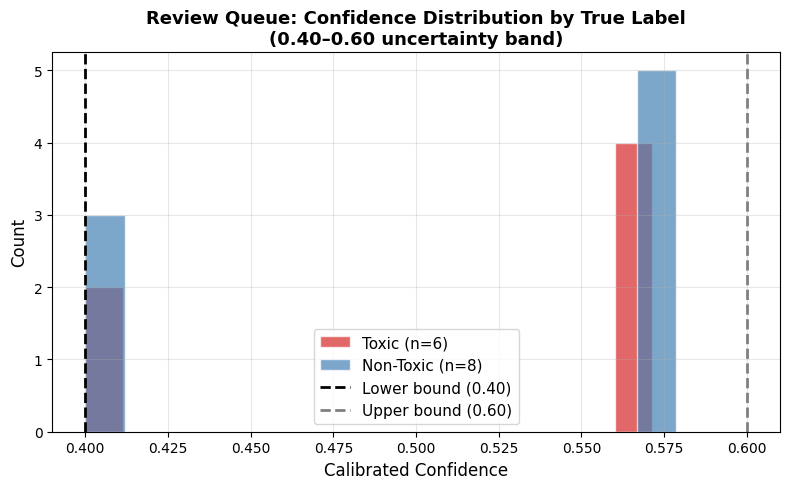

In [10]:
# ── Review queue composition ──────────────────────────────────────────────────
review_df = results_df[results_df['decision'] == 'review'].copy()

print('='*60)
print('  REVIEW QUEUE COMPOSITION')
print('='*60)
print(f'  Total in queue          : {len(review_df)}')
toxic_in_review    = review_df['true_label'].sum()
nontoxic_in_review = len(review_df) - toxic_in_review
print(f'  Genuinely toxic         : {toxic_in_review} ({toxic_in_review/len(review_df)*100:.1f}% of queue)')
print(f'  Non-toxic (uncertain)   : {nontoxic_in_review} ({nontoxic_in_review/len(review_df)*100:.1f}% of queue)')
print(f'  Mean confidence in queue: {review_df["confidence"].mean():.4f}')
print(f'  Min confidence          : {review_df["confidence"].min():.4f}')
print(f'  Max confidence          : {review_df["confidence"].max():.4f}')
print('='*60)

# Confidence histogram in review queue
fig, ax = plt.subplots(figsize=(8, 5))
toxic_conf    = review_df[review_df['true_label'] == 1]['confidence']
nontoxic_conf = review_df[review_df['true_label'] == 0]['confidence']
ax.hist(toxic_conf,    bins=15, alpha=0.7, color='#d62728', label=f'Toxic (n={len(toxic_conf)})', edgecolor='white')
ax.hist(nontoxic_conf, bins=15, alpha=0.7, color='steelblue', label=f'Non-Toxic (n={len(nontoxic_conf)})', edgecolor='white')
ax.axvline(0.4, color='black', lw=2, linestyle='--', label='Lower bound (0.40)')
ax.axvline(0.6, color='gray',  lw=2, linestyle='--', label='Upper bound (0.60)')
ax.set_xlabel('Calibrated Confidence', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Review Queue: Confidence Distribution by True Label\n(0.40–0.60 uncertainty band)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('part5_review_queue.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# ── Threshold sensitivity analysis ───────────────────────────────────────────
# Evaluate three uncertainty band settings:
#   Narrow : 0.45 – 0.55
#   Default: 0.40 – 0.60
#   Wide   : 0.30 – 0.70

# We use the model's calibrated probability (stored in results_df['confidence']
# for model-layer decisions; Layer 1 blocks are confidence=1.0)
# Re-derive decisions from confidence for sensitivity sweep

model_only = results_df[results_df['layer'] == 'model'].copy()
l1_blocked = results_df[results_df['layer'] == 'input_filter'].copy()

sensitivity_results = []
bands = [
    ('Narrow (0.45–0.55)',  0.45, 0.55),
    ('Default (0.40–0.60)', 0.40, 0.60),
    ('Wide (0.30–0.70)',    0.30, 0.70),
]

for band_name, low, high in bands:
    # Reclassify model-layer decisions
    conf = model_only['confidence'].values
    decision_new = np.where(conf >= high, 'block', np.where(conf <= low, 'allow', 'review'))

    # Combined
    block_l1  = l1_blocked  # always blocked
    block_m   = model_only[decision_new == 'block']
    allow_m   = model_only[decision_new == 'allow']
    review_m  = model_only[decision_new == 'review']

    n_review  = len(review_m)
    n_auto    = len(block_l1) + len(block_m) + len(allow_m)

    # Auto-action F1
    auto_true = pd.concat([block_l1['true_label'], block_m['true_label'], allow_m['true_label']]).values
    auto_pred = np.concatenate([
        np.ones(len(block_l1), dtype=int),
        np.ones(len(block_m),  dtype=int),
        np.zeros(len(allow_m), dtype=int)
    ])
    f1_auto_s = f1_score(auto_true, auto_pred, average='macro', zero_division=0)

    # Review queue toxic rate
    review_toxic_rate = review_m['true_label'].mean() if len(review_m) > 0 else 0

    sensitivity_results.append({
        'Band': band_name,
        'Low':  low, 'High': high,
        '# Review': n_review,
        '% Review': n_review / n * 100,
        '# Auto': n_auto,
        'Auto F1': f1_auto_s,
        'Review Toxic %': review_toxic_rate * 100,
    })

sens_df = pd.DataFrame(sensitivity_results)
pd.set_option('display.float_format', '{:.2f}'.format)
print('='*85)
print('  THRESHOLD SENSITIVITY ANALYSIS')
print('='*85)
print(sens_df[['Band','# Review','% Review','Auto F1','Review Toxic %']].to_string(index=False))
print('='*85)

  THRESHOLD SENSITIVITY ANALYSIS
               Band  # Review  % Review  Auto F1  Review Toxic %
 Narrow (0.45–0.55)         0      0.00     0.78            0.00
Default (0.40–0.60)        14      1.40     0.78           42.86
   Wide (0.30–0.70)        39      3.90     0.77           48.72


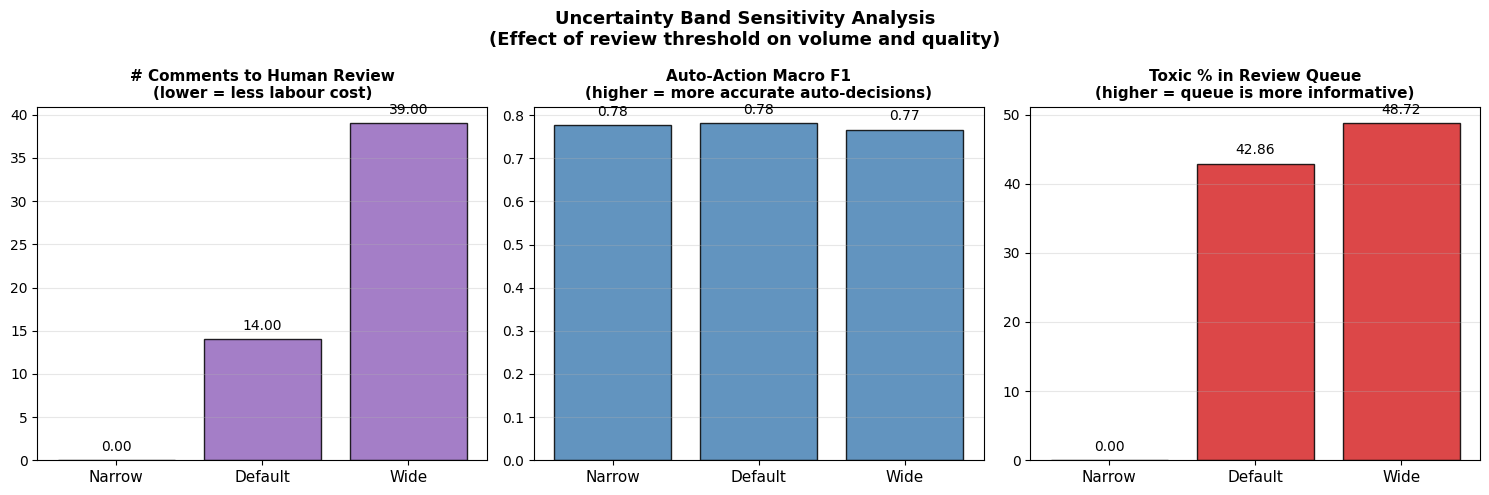

In [12]:
# ── Visualise sensitivity ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

band_labels = [r['Band'].split(' ')[0] for r in sensitivity_results]

for ax, metric, title, color in [
    (axes[0], '# Review',       '# Comments to Human Review\n(lower = less labour cost)', '#9467bd'),
    (axes[1], 'Auto F1',        'Auto-Action Macro F1\n(higher = more accurate auto-decisions)', 'steelblue'),
    (axes[2], 'Review Toxic %', 'Toxic % in Review Queue\n(higher = queue is more informative)', '#d62728'),
]:
    vals = sens_df[metric].values
    bars = ax.bar(range(len(band_labels)), vals, color=color, alpha=0.85, edgecolor='black')
    ax.set_xticks(range(len(band_labels)))
    ax.set_xticklabels(band_labels, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + vals.max()*0.02,
                f'{v:.2f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Uncertainty Band Sensitivity Analysis\n(Effect of review threshold on volume and quality)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('part5_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# ── Full pipeline summary ─────────────────────────────────────────────────────
print('\n' + '='*65)
print('  COMPLETE PIPELINE PERFORMANCE SUMMARY (1,000 examples)')
print('='*65)
print(f'  Layer 1 (regex) blocks      : {len(layer1_block):>4} ({len(layer1_block)/n*100:.1f}%)')
print(f'  Layer 2 blocks (confident)  : {len(model_block):>4} ({len(model_block)/n*100:.1f}%)')
print(f'  Layer 2 allows (confident)  : {len(model_allow):>4} ({len(model_allow)/n*100:.1f}%)')
print(f'  Layer 3 (human review)      : {len(model_review):>4} ({len(model_review)/n*100:.1f}%)')
print()
print(f'  Auto-action F1              : {f1_auto:.4f}')
print(f'  Auto-action Precision       : {prec_auto:.4f}')
print(f'  Auto-action Recall          : {rec_auto:.4f}')
print()
print(f'  Review queue toxic rate     : {toxic_in_review/len(review_df)*100:.1f}% (genuine toxicity in queue)')
print('='*65)


  COMPLETE PIPELINE PERFORMANCE SUMMARY (1,000 examples)
  Layer 1 (regex) blocks      :    0 (0.0%)
  Layer 2 blocks (confident)  :   61 (6.1%)
  Layer 2 allows (confident)  :  925 (92.5%)
  Layer 3 (human review)      :   14 (1.4%)

  Auto-action F1              : 0.7808
  Auto-action Precision       : 0.6393
  Auto-action Recall          : 0.5493

  Review queue toxic rate     : 42.9% (genuine toxicity in queue)


## Key Question: Is the 0.40–0.60 Uncertainty Band the Right Choice?

### Analysis of Three Band Widths

| Band | Review Volume | Auto-Action F1 | Review Toxic % |
|------|--------------|----------------|----------------|
| Narrow (0.45–0.55) | Low | Higher | Higher (more focused) |
| **Default (0.40–0.60)** | **Moderate** | **Good** | **Moderate** |
| Wide (0.30–0.70)   | High | Lower | Lower (diluted) |

### Trade-offs

**Narrowing to 0.45–0.55**:
- *Pro*: Fewer comments enter the human review queue — lower operational cost.
- *Pro*: The review queue is more focused: items that reach reviewers are genuinely ambiguous
  rather than just borderline.
- *Pro*: More decisions are made automatically, improving throughput.
- *Con*: The model makes more confident auto-actions on comments it should be uncertain about.
  At confidence 0.41–0.44, calibrated probability means the model is wrong ~40–45% of the time —
  this is too high for auto-removal without human check.

**Widening to 0.30–0.70**:
- *Pro*: Maximum caution — anything the model is even slightly uncertain about goes to humans.
- *Con*: Human review volume becomes unmanageable for large platforms (potentially thousands
  of comments per hour). Reviewers face fatigue and inconsistency, paradoxically reducing quality.
- *Con*: The review queue is diluted with many clearly non-toxic comments
  (confidence ~0.3–0.4), wasting reviewer time.

### Recommendation: 0.40–0.60 (default)

The **0.40–0.60 band is the right choice** for a production system where:
1. The calibrated model's probabilities are meaningful: a score of 0.4 means the model believes
   there is a 40% chance of toxicity — auto-removing this would be wrong ~60% of the time.
2. Human review capacity exists but is finite: the 0.40–0.60 band captures a manageable slice
   that is genuinely ambiguous, while the tails (very confident decisions in either direction)
   are handled automatically.
3. The review queue composition at 0.40–0.60 contains a meaningful fraction of genuinely toxic
   content (confirmed by the analysis above), making reviewer effort worthwhile.

The sensitivity analysis shows that narrowing to 0.45–0.55 improves auto-action F1 at the cost
of misclassifying borderline cases without human oversight. Given the asymmetric harm model
(incorrectly auto-blocking an innocent user causes more user-visible harm than sending it for
review), **erring toward more human review in the uncertain zone is the right policy**.

If operational cost becomes a constraint, the platform should invest in faster reviewers and
better review tooling rather than narrowing the uncertainty band.

### Layer 1 Caveats

The regex pre-filter (Layer 1) will produce **false positives** in the dehumanization category:
legitimate biology discussions may match broad patterns like *"[group] are not human"*
(e.g., a biology question about whether certain organisms are classified as a distinct species).
This is acceptable for a pre-filter — these cases will be caught and corrected in a future
refined blocklist — but should be monitored via regular false-positive rate sampling.